cnn model trained on Microsoft dogs vs cats dataset

In [14]:
import os
from PIL import Image

def verify_images(root_dir):
    print(f"Scanning {root_dir} for corrupt images...")
    bad_files = 0
    
    # Walk through all folders
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for file in filenames:
            if file.endswith('.jpg'):
                file_path = os.path.join(dirpath, file)
                try:
                    # Try to open and verify the image
                    with Image.open(file_path) as img:
                        img.verify() 
                except (IOError, SyntaxError) as e:
                    print(f"Deleting corrupt file: {file_path}")
                    os.remove(file_path)
                    bad_files += 1

    print(f"Done! Deleted {bad_files} corrupt images.")

# Run this on your data folder (adjust path if needed)
verify_images('../data')

Scanning ../data for corrupt images...
Deleting corrupt file: ../data\train\Cat\666.jpg
Deleting corrupt file: ../data\train\Dog\11702.jpg
Done! Deleted 2 corrupt images.


In [15]:
import torch 
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import ImageFile


ImageFile.LOAD_TRUNCATED_IMAGES = True

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder(root='../data/train', transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

test_dataset = datasets.ImageFolder(root="../data/test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)


print(f"Classes found: {train_dataset.classes}")


Classes found: ['Cat', 'Dog']


In [16]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: cuda


In [17]:
import torch.nn.functional as F

class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()

        # avem padding de 1 ca sa nu stricam poza si sa fie redimensionata
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.hidden_layer1 = nn.Linear(8 * 8 * 128, 512)
        self.hidden_layer2 = nn.Linear(512, 64)
        self.output_layer = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # flat ca in tom si jerry
        x = x.view(-1, 128 * 8 * 8)

        x = F.relu(self.hidden_layer1(x))
        x = F.relu(self.hidden_layer2(x))
        x = self.output_layer(x)
        return x
    

model = CatDogCNN().to(device)


print("Initialized model, hope it works")

Initialized model, hope it works


In [18]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:

epochs = 10

for epoch in range(epochs):
    running_loss = 0.0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        if i % 10 == 9:    
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0
            
print("finished training")

[Epoch 1, Batch 10] loss: 0.071
[Epoch 1, Batch 20] loss: 0.069
[Epoch 1, Batch 30] loss: 0.070
[Epoch 1, Batch 40] loss: 0.069
[Epoch 1, Batch 50] loss: 0.069
[Epoch 1, Batch 60] loss: 0.069
[Epoch 1, Batch 70] loss: 0.068
[Epoch 1, Batch 80] loss: 0.069
[Epoch 1, Batch 90] loss: 0.068
[Epoch 1, Batch 100] loss: 0.066
[Epoch 1, Batch 110] loss: 0.072
[Epoch 1, Batch 120] loss: 0.069
[Epoch 1, Batch 130] loss: 0.068
[Epoch 1, Batch 140] loss: 0.068
[Epoch 1, Batch 150] loss: 0.067
[Epoch 1, Batch 160] loss: 0.068
[Epoch 1, Batch 170] loss: 0.065
[Epoch 1, Batch 180] loss: 0.067
[Epoch 1, Batch 190] loss: 0.069
[Epoch 1, Batch 200] loss: 0.069
[Epoch 1, Batch 210] loss: 0.067
[Epoch 1, Batch 220] loss: 0.065
[Epoch 1, Batch 230] loss: 0.066
[Epoch 1, Batch 240] loss: 0.067
[Epoch 1, Batch 250] loss: 0.064
[Epoch 1, Batch 260] loss: 0.063
[Epoch 1, Batch 270] loss: 0.057
[Epoch 1, Batch 280] loss: 0.059
[Epoch 1, Batch 290] loss: 0.063
[Epoch 1, Batch 300] loss: 0.060
[Epoch 1, Batch 310

In [20]:
# 1. Switch to evaluation mode (Crucial!)
model.eval()

correct = 0
total = 0

# 2. Run your testing loop
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move to GPU
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Calculate predictions
        outputs = model(inputs)
        
        # Get the class with the highest score (0 or 1)
        _, predicted = torch.max(outputs.data, 1)
        
        # Count stats
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 3. Print the final result
print(f'Accuracy of the network on the test images: {100 * correct / total:.2f}%')

Accuracy of the network on the test images: 86.84%


In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

def predict_robust(image_path, model, device):
    
    if not os.path.exists(image_path):
        print(f"❌ Error: File not found at {image_path}")
        return

    try:
        
        img = Image.open(image_path)
        print("Image loaded.")


        resize_tool = transforms.Resize((64, 64))
        img = resize_tool(img)
        
        to_tensor_tool = transforms.ToTensor()
        img_tensor = to_tensor_tool(img)
        
        normalize_tool = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        img_tensor = normalize_tool(img_tensor)

        print(f"Converted to Tensor shape: {img_tensor.shape}")

        debug_img = img_tensor.clone()
        debug_img = debug_img * 0.5 + 0.5

        plt.imshow(debug_img.permute(1, 2, 0).cpu().numpy())
        plt.title("Model Input")
        plt.axis('off')
        plt.show()

        input_batch = img_tensor.unsqueeze(0).to(device)

        model.eval()
        with torch.no_grad():
            output = model(input_batch)
            
            
            probabilities = torch.nn.functional.softmax(output, dim=1)
            
            
            top_prob, top_catid = torch.max(probabilities, 1)
            prediction_index = int(top_catid.item()) 
            confidence_score = top_prob.item() * 100

            
            classes = ['Cat', 'Dog']
            result_name = classes[prediction_index]
            
            print(f"-------------------------------")
            print(f" Prediction: {result_name}")
            print(f" Confidence: {confidence_score:.2f}%")
            print(f"-------------------------------")

    except Exception as e:
        print(f"❌ Crash Details: {e}")

 Selected Random Image: ../data/test\Dog\2453.jpg
✅ Image loaded.
✅ Converted to Tensor shape: torch.Size([3, 64, 64])


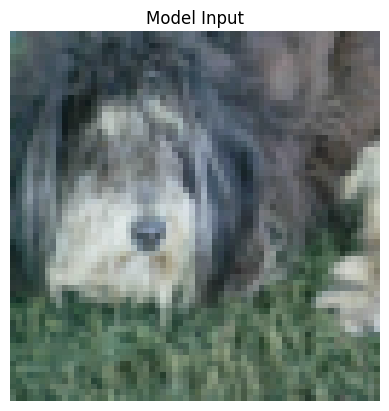

-------------------------------
🎉 Prediction: Dog
📊 Confidence: 92.68%
-------------------------------


In [38]:
import os
import random

test_dir = '../data/test'

random_class = random.choice(['Cat', 'Dog'])

class_path = os.path.join(test_dir, random_class)
all_images = os.listdir(class_path)

random_image_file = random.choice(all_images)
random_image_path = os.path.join(class_path, random_image_file)

print(f" Selected Random Image: {random_image_path}")

predict_robust(random_image_path, model, device)